1. Генератор данных: обновить генератор данных для решения задачи сегментации и подсчета количества клеток. На выходе:количество классов и сегментационные маски. Для отделения сегментационных масок можете использовать методы математической морфологии.
2. Натренировать модель yolo для решения задачи сегментации и определения количества клеток. Количество клеток - класс изображения.

Dataset: https://www.kaggle.com/datasets/jeetblahiri/bccd-dataset-with-mask

In [1]:
import os
import math
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
import torchvision.transforms as v2
from torchvision import models
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
from ultralytics import YOLO
import numpy as np
import cv2
import json
import itertools

In [2]:
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Init generator

In [3]:
files_path = "lab2/dataset_1"
masks_files = os.listdir(files_path + "/mask")
originals_files = os.listdir(files_path + "/original")
masks_files, originals_files

(['e6a7743e-4040-40fa-b097-ca6874c469b7.png',
  'e3c1442a-717f-41dd-bf97-81e1233ac9fa.png',
  'e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png',
  'e4eea7ea-8989-46a9-9c98-25a178146b28.png',
  'e3ade58d-086c-47fa-9120-76beacb45395.png',
  'e3e9c2de-0a24-4c7e-8a69-3d3093d5bdab.png',
  'e5fd5949-4cd0-4cb6-837a-02c26a5eb87a.png',
  'e9e78ff8-831b-46e9-9785-3eee9acbfcd8.png',
  'e6d7c5e1-43fc-4712-86d5-aa70252b978f.png',
  'e98ea067-82b5-4a0d-87bf-b4bbdc10ddab.png'],
 ['e3c1442a-717f-41dd-bf97-81e1233ac9fa.png',
  'e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png',
  'e4eea7ea-8989-46a9-9c98-25a178146b28.png',
  'e6a7743e-4040-40fa-b097-ca6874c469b7.jpg',
  'e3ade58d-086c-47fa-9120-76beacb45395.png',
  'e3e9c2de-0a24-4c7e-8a69-3d3093d5bdab.png',
  'e5fd5949-4cd0-4cb6-837a-02c26a5eb87a.png',
  'e9e78ff8-831b-46e9-9785-3eee9acbfcd8.png',
  'e6d7c5e1-43fc-4712-86d5-aa70252b978f.png',
  'e98ea067-82b5-4a0d-87bf-b4bbdc10ddab.png'])

In [4]:
dataset_prep = {}
for m in masks_files:
    image_name = m.split(".")[0]
    o = None
    for _o in originals_files:
        if _o.startswith(image_name):
            o = _o
            break
    assert(o is not None)
    dataset_prep[image_name] = {
        "mask_file": files_path + "/mask/" + m,
        "original_file": files_path + "/original/" + o,
    }
dataset_prep

{'e6a7743e-4040-40fa-b097-ca6874c469b7': {'mask_file': 'lab2/dataset_1/mask/e6a7743e-4040-40fa-b097-ca6874c469b7.png',
  'original_file': 'lab2/dataset_1/original/e6a7743e-4040-40fa-b097-ca6874c469b7.jpg'},
 'e3c1442a-717f-41dd-bf97-81e1233ac9fa': {'mask_file': 'lab2/dataset_1/mask/e3c1442a-717f-41dd-bf97-81e1233ac9fa.png',
  'original_file': 'lab2/dataset_1/original/e3c1442a-717f-41dd-bf97-81e1233ac9fa.png'},
 'e13f2327-fbf4-4d84-a8c1-09cb1e449c8c': {'mask_file': 'lab2/dataset_1/mask/e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png',
  'original_file': 'lab2/dataset_1/original/e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png'},
 'e4eea7ea-8989-46a9-9c98-25a178146b28': {'mask_file': 'lab2/dataset_1/mask/e4eea7ea-8989-46a9-9c98-25a178146b28.png',
  'original_file': 'lab2/dataset_1/original/e4eea7ea-8989-46a9-9c98-25a178146b28.png'},
 'e3ade58d-086c-47fa-9120-76beacb45395': {'mask_file': 'lab2/dataset_1/mask/e3ade58d-086c-47fa-9120-76beacb45395.png',
  'original_file': 'lab2/dataset_1/original/e3ade58d-

In [5]:
dump_dataset_prep = False

In [6]:
def get_background_color(a):
    colors, count = np.unique(a.reshape(-1, a.shape[-1]), axis=0, return_counts=True)
    count_sorted_arg = np.flip(np.argsort(count))
    if np.equal(colors[count_sorted_arg[0]], [0, 0, 0]).all():
        return colors[count_sorted_arg[1]]
    else:
        return colors[count_sorted_arg[0]]

for key, value in dataset_prep.items():
    mask = cv2.imread(value["mask_file"])
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    img = cv2.imread(value["original_file"])
    mask_filtered = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)), iterations=3)

    background = img.copy()
    background[mask_filtered > 0] = np.array([0, 0, 0], dtype=np.uint8)
    background_color = get_background_color(background)
    background[mask_filtered > 0] = background_color

    value["background_color"] = background_color
    value["background"] = background

    cells_img = img.copy()
    cells_img[mask == 0] = np.array([0, 0, 0], dtype=np.uint8)
    cells_color = get_background_color(cells_img)
    value["cells_color"] = cells_color

    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=4)
    cells = []
    cells_size_range  = [np.max(img.shape), 0]
    for i in range(1, len(stats)):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        if w > 1 and h > 1: # Sometimes weird 1x1 objects are created, gotta exclude those
            curr_cell = img[y:y+h, x:x+w].copy()
            curr_cell[(labels[y:y+h, x:x+w] != i) > 0] = np.array([0, 0, 0], dtype=np.uint8)
            cells.append(curr_cell)
            cells_size_range[0] = min(cells_size_range[0], w, h)
            cells_size_range[1] = max(cells_size_range[1], w, h)
    cells_size_range = list(map(int, cells_size_range))

    value["cells"] = cells
    value["cells_size_range"] = cells_size_range

    if dump_dataset_prep:
        dump_path = files_path + "/generator_dumps/" + key
        os.makedirs(dump_path, exist_ok=True)
        cv2.imwrite(dump_path + "/background.png", background)
        for i, c in enumerate(cells):
            cv2.imwrite(dump_path + "/" + str(i) + ".png", c)
        with open(dump_path + "/additional_data.json", "w", encoding="utf-8") as f:
            json.dump(
                {
                    "background_color": background_color.tolist(),
                    "cells_size_range": cells_size_range,
                    "cells_color": cells_color.tolist(),
                }, f, ensure_ascii=False)
dataset_prep[list(dataset_prep.keys())[0]].keys()

dict_keys(['mask_file', 'original_file', 'background_color', 'background', 'cells_color', 'cells', 'cells_size_range'])

## Test

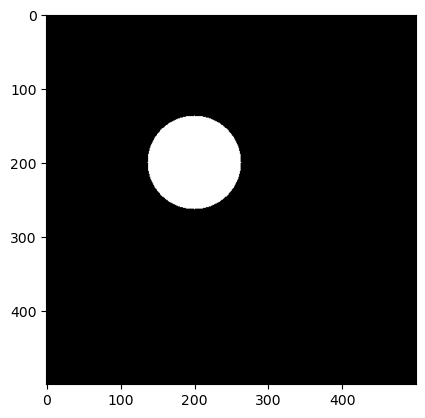

In [7]:
test_circle = np.zeros((500, 500), dtype=np.uint8)
cv2.circle(test_circle, (200, 200), 63, 1, -1)
plt.imshow(test_circle, cmap="gray")

8
(8, 1, 2)


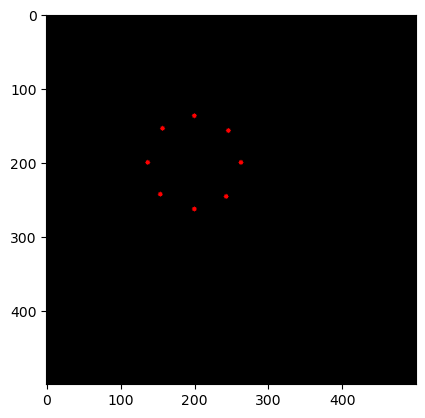

In [26]:
contours, hierarchy = cv2.findContours(test_circle, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_L1)
contours = contours[0]
epsilon = 0.015*cv2.arcLength(contours, True)
contours = cv2.approxPolyDP(contours, epsilon, True)
test_circle_rgb = np.zeros((test_circle.shape[0], test_circle.shape[1], 3), dtype=np.uint8)
#test_circle_rgb[test_circle > 0] = (255, 255, 255)
print(len(contours))
print(contours.shape)
cv2.drawContours(test_circle_rgb, contours, -1, (255, 0, 0), 5)
plt.imshow(test_circle_rgb)

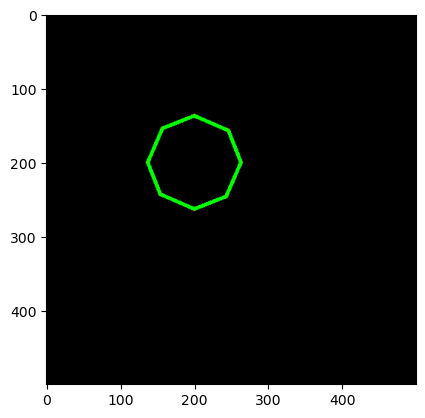

In [27]:
cv2.polylines(test_circle_rgb, [contours], True, (0, 255, 0), 3)
plt.imshow(test_circle_rgb)

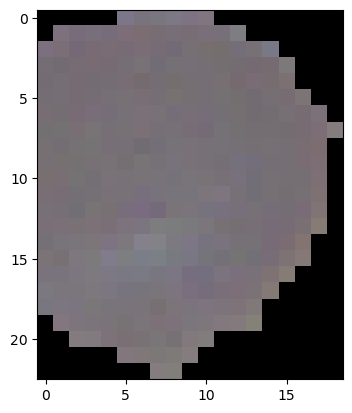

In [10]:
test_subject = 'e6a7743e-4040-40fa-b097-ca6874c469b7'
cell_img = dataset_prep[test_subject]["cells"][4]
cell_img = cv2.resize(cell_img, None, fx=0.2, fy=0.2)
plt.imshow(cell_img)

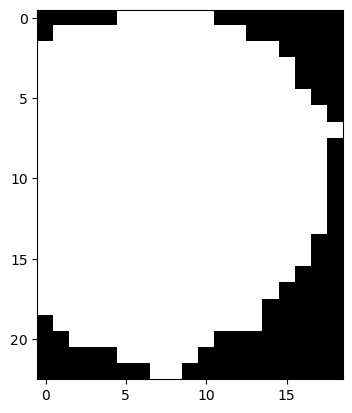

In [11]:
_, cell_mask = cv2.threshold(cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY), 1, 255, cv2.THRESH_BINARY)
plt.imshow(cell_mask, cmap="gray")

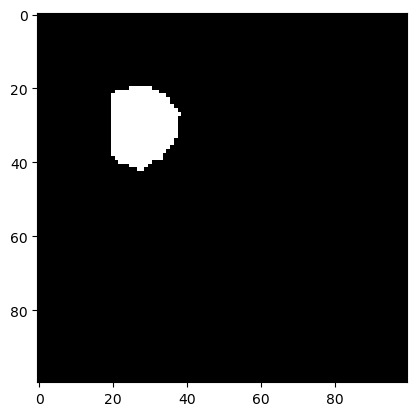

In [12]:
test_cell_image = np.zeros((100, 100), dtype=np.uint8)
test_cell_image[20:cell_mask.shape[0]+20, 20:cell_mask.shape[1]+20] = cell_mask[:, :]
plt.imshow(test_cell_image, cmap="gray")

9
(9, 1, 2)


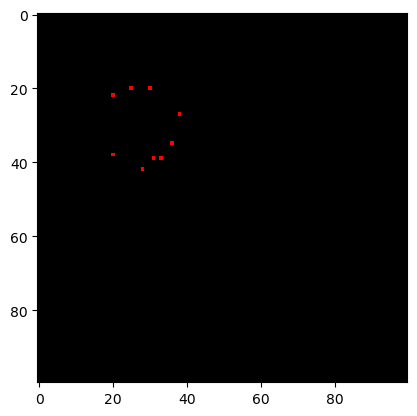

In [28]:
contours, hierarchy = cv2.findContours(test_cell_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_L1)
contours = contours[0]
epsilon = 0.015*cv2.arcLength(contours, True)
contours = cv2.approxPolyDP(contours, epsilon, True)
test_cell_image_rgb = np.zeros((test_cell_image.shape[0], test_cell_image.shape[1], 3), dtype=np.uint8)
#test_cell_image_rgb[test_cell_image > 0] = (255, 255, 255)
print(len(contours))
print(contours.shape)
cv2.drawContours(test_cell_image_rgb, contours, -1, (255, 0, 0), 1)
plt.imshow(test_cell_image_rgb)

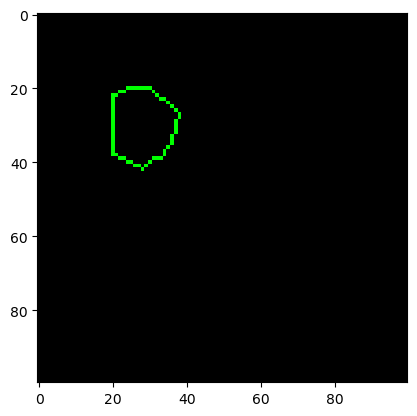

In [29]:
cv2.polylines(test_cell_image_rgb, [contours], True, (0, 255, 0), 1)
plt.imshow(test_cell_image_rgb)

## Dataset

In [30]:
class BloodCellsDataset(Dataset):

    def __init__(
        self,
        device,
        img_size: tuple[int, int], # (w, h)
        dataset_size: int,
        dataset_prep: dict,
        clamp_imgs_to_0_1: bool = False,
        check_individual_coverage: bool = True, # Disable for faster generation
        p_background_solid: float = 0.5,
        p_cell_artificial: float = 0.5,
        min_cells_count: int = 40,
        max_cells_count: int = 100,
        min_cell_coverage: float = 0.25,
        gauss_noise_params_ranges: tuple[tuple[float, float], tuple[float, float]] = (0, 50),
        uniform_noise_params_ranges: tuple[tuple[float, float], tuple[float, float]] = (-100, 100),
        periodic_noise_params_ranges: tuple[tuple[float, float], tuple[float, float], tuple[float, float], tuple[float, float]] = (40, 40, 80, 0),
        p_noise_select: list[float] = [], # [gauss, uniform, periodic]
        noise_clamp: bool = True, # clamps resulting noisy image
        noise_grayscale: bool = True,
        mix_cells_datasets: bool = False,
        no_out_of_bounds: bool = False,
    ):
        self.device = device
        self.img_size = img_size
        assert(img_size[0] > 0 and img_size[1] > 0)
        self.dataset_size = dataset_size
        assert(dataset_size > 0)
        self.dataset_prep = dataset_prep
        self.clamp_imgs_to_0_1 = clamp_imgs_to_0_1
        self.min_cells_count = min_cells_count
        self.max_cells_count = max_cells_count
        assert(0 < min_cells_count <= max_cells_count)
        self.check_individual_coverage = check_individual_coverage
        self.p_background_solid = p_background_solid
        assert(0 <= p_background_solid <= 1)
        self.p_cell_artificial = p_cell_artificial
        assert(0 <= p_cell_artificial <= 1)
        self.min_cell_coverage = min_cell_coverage
        assert(0 <= min_cell_coverage <= 1)
        _gauss_noise_params_ranges = []
        for i in range(2):
            if not hasattr(gauss_noise_params_ranges[i], "__getitem__"):
                _gauss_noise_params_ranges.append((gauss_noise_params_ranges[i], gauss_noise_params_ranges[i]))
            else:
                _gauss_noise_params_ranges.append(gauss_noise_params_ranges[i])
            assert(_gauss_noise_params_ranges[i][0] <= _gauss_noise_params_ranges[i][1])
        _gauss_noise_params_ranges = tuple(_gauss_noise_params_ranges)
        assert(_gauss_noise_params_ranges[1][0] >= 0)
        assert(_gauss_noise_params_ranges[1][1] >= 0)
        self.gauss_noise_params_ranges = _gauss_noise_params_ranges
        _uniform_noise_params_ranges = []
        for i in range(2):
            if not hasattr(uniform_noise_params_ranges[i], "__getitem__"):
                _uniform_noise_params_ranges.append((uniform_noise_params_ranges[i], uniform_noise_params_ranges[i]))
            else:
                _uniform_noise_params_ranges.append(uniform_noise_params_ranges[i])
        _uniform_noise_params_ranges = tuple(_uniform_noise_params_ranges)
        self.uniform_noise_params_ranges = _uniform_noise_params_ranges
        _periodic_noise_params_ranges = []
        for i in range(4):
            if not hasattr(periodic_noise_params_ranges[i], "__getitem__"):
                _periodic_noise_params_ranges.append((periodic_noise_params_ranges[i], periodic_noise_params_ranges[i]))
            else:
                _periodic_noise_params_ranges.append(periodic_noise_params_ranges[i])
        _periodic_noise_params_ranges = tuple(_periodic_noise_params_ranges)
        self.periodic_noise_params_ranges = _periodic_noise_params_ranges
        noise_types_count = 3
        assert(len(p_noise_select) <= noise_types_count)
        assert(len(p_noise_select) == noise_types_count and sum(p_noise_select) == 1.0 or len(p_noise_select) < noise_types_count and sum(p_noise_select) <= 1.0)
        if len(p_noise_select) < noise_types_count:
            self.p_noise_select = p_noise_select + [(1.0 - sum(p_noise_select)) / (noise_types_count - len(p_noise_select))] * (noise_types_count - len(p_noise_select))
        else:
            self.p_noise_select = p_noise_select
        self.noise_clamp = noise_clamp
        self.noise_grayscale = noise_grayscale
        self.mix_cells_datasets = mix_cells_datasets
        self.no_out_of_bounds = no_out_of_bounds

        self.generated_result_cells_dataset_keys = [None] * dataset_size
        self.generated_result_background_dataset_keys = [None] * dataset_size
        self.generated_results = []
        for i in range(dataset_size):
            self.generated_results.append(self.generate_result(i))

    def __len__(self) -> int:
        return self.dataset_size

    def __getitem__(self, item: int):
        assert(item >= 0 and item < self.__len__())
        return self.generated_results[item]

    def generate_result(self, index: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, str, torch.Tensor, tuple[torch.Tensor]]:
        # Determine cells count
        cells_count = np.random.randint(self.min_cells_count, self.max_cells_count)
        # Select first cells dataset
        cells_dataset_key = self.choose_random_dataset()
        self.generated_result_cells_dataset_keys[index] = cells_dataset_key
        cells_dataset = self.dataset_prep[cells_dataset_key]
        cells_size_range = cells_dataset["cells_size_range"]
        # Generate background
        clean_img = self.select_background(index)
        # Init masks and imgs
        cells_mask = np.zeros((clean_img.shape[0], clean_img.shape[1]), clean_img.dtype)
        cells_img = np.zeros_like(clean_img)
        temp_img = np.zeros_like(cells_img)
        temp_mask_history = []
        cells_bounding_boxes = []
        cells_bounding_polys = []
        # Begin
        actual_cells_count = 0
        for i in range(cells_count):
            for _max_attempts in range(999):
                # Reset temp
                temp_mask = np.zeros_like(cells_mask)
                temp_img.fill(0)
                cell_bounding_box = None
                # Select another cells dataset if mix_cells_datasets
                if self.mix_cells_datasets:
                    cells_dataset_key = self.choose_random_dataset()
                    cells_dataset = self.dataset_prep[cells_dataset_key]
                    cells_size_range = cells_dataset["cells_size_range"]
                # Select cell pos
                x = np.random.randint(cells_img.shape[1])
                y = np.random.randint(cells_img.shape[0])
                # select if generating artificial cell
                use_artificial_cell = bool(np.random.choice(2, p=[1-self.p_cell_artificial, self.p_cell_artificial]))

                if use_artificial_cell:
                    rad = np.random.randint(cells_size_range[0]//2, cells_size_range[1]//2)
                    cv2.circle(temp_mask, center=(x, y), radius=rad, color=255, thickness=-1)
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=cells_dataset["cells_color"].tolist(), thickness=-1)
                    stroke_color = 255 - cells_dataset["cells_color"]
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=stroke_color.tolist(), thickness=3)
                    cell_bounding_box = [x, y, rad*2, rad*2]
                else:
                    cell_index = np.random.randint(len(cells_dataset["cells"]))
                    cell_img = cells_dataset["cells"][cell_index]
                    cell_bounding_box = [x, y, cell_img.shape[1], cell_img.shape[0]]
                    _, cell_mask = cv2.threshold(cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY), 3, 255, cv2.THRESH_BINARY)
                    temp_mask = self.overlay_image_center(temp_mask, cell_mask, x, y)
                    temp_img = self.overlay_image_center(temp_img, cell_img, x, y)
                if self.no_out_of_bounds and not self.is_rect_inside_img(cell_bounding_box, cells_img.shape):
                    continue
                # Insert generated cell
                temp_mask_without = cv2.bitwise_and(temp_mask, cv2.bitwise_not(cells_mask))
                coverage = np.count_nonzero(temp_mask_without) / np.count_nonzero(temp_mask)
                can_insert = coverage >= self.min_cell_coverage
                if self.check_individual_coverage and can_insert:
                    for prev_temp_mask in temp_mask_history:
                        if np.count_nonzero(cv2.bitwise_and(temp_mask, prev_temp_mask)) > 0:
                            temp_mask_without_ind = cv2.bitwise_and(temp_mask, cv2.bitwise_not(prev_temp_mask))
                            prev_temp_mask_without = cv2.bitwise_and(prev_temp_mask, cv2.bitwise_not(temp_mask))
                            # Check coverage
                            coverage = np.count_nonzero(temp_mask_without_ind) / np.count_nonzero(temp_mask)
                            prev_coverage = np.count_nonzero(prev_temp_mask_without) / np.count_nonzero(prev_temp_mask)
                            if coverage < self.min_cell_coverage or prev_coverage < self.min_cell_coverage:
                                can_insert = False
                                break
                if can_insert:
                    cells_img = self.add_image_with_mask(cells_img, temp_img, temp_mask_without)
                    cells_mask = self.add_image_with_mask(cells_mask, temp_mask, temp_mask_without)
                    if self.check_individual_coverage:
                        temp_mask_history.append(temp_mask)
                    contours, hierarchy = cv2.findContours(temp_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_TC89_L1)
                    contours = contours[0]
                    epsilon = 0.015*cv2.arcLength(contours, True)
                    contours = cv2.approxPolyDP(contours, epsilon, True).astype(float).reshape(-1, 2)
                    contours /= np.array([temp_mask.shape[1], temp_mask.shape[0]], dtype=float)
                    for j in range(4):
                        cell_bounding_box[j] /= clean_img.shape[1 - j % 2]
                    cells_bounding_boxes.append(cell_bounding_box)
                    cells_bounding_polys.append(contours)
                    actual_cells_count += 1
                    break
            else:
                print("Warning: loop ended earlier")
                break
        # add background
        clean_img = self.add_image_with_mask(clean_img, cells_img, cells_mask)
        # resize
        clean_img = cv2.resize(clean_img, dsize=(self.img_size[1], self.img_size[0])).astype(float)
        # create noisy
        noisy_img, noise_type = self.add_noise(clean_img)
        if self.clamp_imgs_to_0_1:
            clean_img = clean_img / 255.0
            noisy_img = noisy_img / 255.0

        return (
            torch.FloatTensor(clean_img).to(self.device),
            torch.FloatTensor(noisy_img).to(self.device),
            torch.FloatTensor([actual_cells_count]).to(self.device),
            noise_type,
            torch.FloatTensor(cells_bounding_boxes).to(self.device),
            #torch.FloatTensor(cells_bounding_polys).to(self.device)
            tuple(map(lambda x: torch.FloatTensor(x).to(self.device), cells_bounding_polys))
        )

    def choose_random_dataset(self) -> str:
        return np.random.choice(list(self.dataset_prep.keys()))

    def select_background(self, index: int) -> np.ndarray[np.uint8]:
        background_dataset_key = self.choose_random_dataset()
        self.generated_result_background_dataset_keys[index] = background_dataset_key
        background_dataset = self.dataset_prep[background_dataset_key]
        use_solid_background = bool(np.random.choice(2, p=[1-self.p_background_solid, self.p_background_solid]))
        clean_img = None
        if use_solid_background:
            clean_img = np.zeros_like(background_dataset["background"]) + background_dataset["background_color"]
        else:
            clean_img = background_dataset["background"].copy()
        return clean_img

    def add_noise(self, clean_img: np.ndarray[float]) -> np.ndarray[float]:
        def gauss_noise(noise_img: np.array):
            mean = np.random.uniform(
                self.gauss_noise_params_ranges[0][0],
                self.gauss_noise_params_ranges[0][1]
            )
            std = np.random.uniform(
                self.gauss_noise_params_ranges[1][0],
                self.gauss_noise_params_ranges[1][1]
            )
            cv2.randn(noise_img, mean, std)
        def uniform_noise(noise_img: np.array):
            low = np.random.uniform(
                self.uniform_noise_params_ranges[0][0],
                self.uniform_noise_params_ranges[0][1]
            )
            high = np.random.uniform(
                self.uniform_noise_params_ranges[1][0],
                self.uniform_noise_params_ranges[1][1]
            )
            cv2.randu(noise_img, low, high)
        def periodic_noise(noise_img: np.array):
            freq_x = np.random.uniform(
                self.periodic_noise_params_ranges[0][0],
                self.periodic_noise_params_ranges[0][1]
            )
            freq_y = np.random.uniform(
                self.periodic_noise_params_ranges[1][0],
                self.periodic_noise_params_ranges[1][1]
            )
            amp = np.random.uniform(
                self.periodic_noise_params_ranges[2][0],
                self.periodic_noise_params_ranges[2][1]
            )
            phase = np.random.uniform(
                self.periodic_noise_params_ranges[3][0],
                self.periodic_noise_params_ranges[3][1]
            )
            h, w = noise_img.shape[:2]
            x, y = np.meshgrid(np.arange(w, dtype=float), np.arange(h, dtype=float))
            freq_x_norm = freq_x / w
            freq_y_norm = freq_y / h
            noise_img[:] = (amp * np.cos(2 * np.pi * (freq_x_norm * x + freq_y_norm * y) + phase)).astype(float)
        noise_img = np.zeros((clean_img.shape[0], clean_img.shape[1]), float)
        noisy_img = None
        noise_dict = [
            {
                "name": "gauss",
                "func": gauss_noise,
            },
            {
                "name": "uniform",
                "func": uniform_noise,
            },
            {
                "name": "periodic",
                "func": periodic_noise,
            },
        ]
        use_noise = np.random.choice(len(noise_dict), p=self.p_noise_select)
        noise_type = noise_dict[use_noise]["name"]
        noise_dict[use_noise]["func"](noise_img)
        if not self.noise_grayscale:
            noise_img = cv2.merge([noise_img, noise_img, noise_img])
            noisy_img = cv2.add(clean_img, noise_img)
        else:
            clean_img_grayscale = cv2.cvtColor(clean_img.astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(float)
            noisy_img = cv2.add(clean_img_grayscale, noise_img)
        if self.noise_clamp:
            noisy_img = np.clip(noisy_img, 0, 255)
        return (noisy_img, noise_type)

    @staticmethod
    def add_image_with_mask(a: np.array, b: np.array, mask: np.array)->np.array:
        a1 = cv2.bitwise_and(a, a, mask=cv2.bitwise_not(mask))
        b1 = cv2.bitwise_and(b, b, mask=mask)
        return cv2.add(a1, b1)

    @staticmethod
    def overlay_image_center(background_img, foreground_img, center_x, center_y)->np.array:
        # Get dimensions
        h2, w2 = background_img.shape[:2]
        h1, w1 = foreground_img.shape[:2]

        # Calculate top-left corner of foreground_img based on center position
        x1_start = center_x - w1 // 2
        y1_start = center_y - h1 // 2

        # Calculate boundaries for foreground_img placement
        x1_end = x1_start + w1
        y1_end = y1_start + h1

        # Calculate valid region in background_img (clamp to bounds)
        x2_start = max(0, x1_start)
        y2_start = max(0, y1_start)
        x2_end = min(w2, x1_end)
        y2_end = min(h2, y1_end)

        # Calculate corresponding region in foreground_img
        x1_crop_start = max(0, -x1_start)
        y1_crop_start = max(0, -y1_start)
        x1_crop_end = x1_crop_start + (x2_end - x2_start)
        y1_crop_end = y1_crop_start + (y2_end - y2_start)

        # Create a copy to avoid modifying original
        result = background_img.copy()

        # Only overlay if there's a valid overlap region
        if x2_end > x2_start and y2_end > y2_start:
            # Extract the valid region from foreground_img
            foreground_img_region = foreground_img[y1_crop_start:y1_crop_end, x1_crop_start:x1_crop_end]

            # Overlay onto background_img
            result[y2_start:y2_end, x2_start:x2_end] = foreground_img_region

        return result

    @staticmethod
    def is_rect_inside_img(rect: tuple[4], img_shape: tuple[2])->bool:
        return rect[0] > 0 and rect[1] > 0 and rect[0] + rect[2] < img_shape[1] and rect[1] + rect[3] < img_shape[0]

Cells count: [         14]
Image shape: (1200, 1200, 3)
Polygons shapes:
(12, 2)
(10, 2)
(9, 2)
(9, 2)
(11, 2)
(9, 2)
(9, 2)
(8, 2)
(10, 2)
(10, 2)
(10, 2)
(11, 2)
(8, 2)
(10, 2)


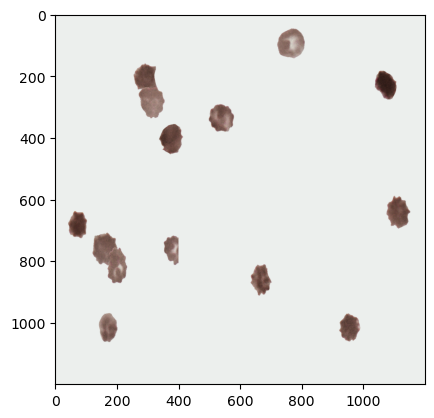

In [31]:
sample = list(BloodCellsDataset(device, (1200, 1200), 1, dataset_prep, min_cells_count=5, max_cells_count=20, p_cell_artificial=0.0, no_out_of_bounds=True)[0])
sample[0] = sample[0].cpu().numpy()
sample = tuple(sample)
bounding_polygons = list(map(lambda x: x.cpu().numpy(), sample[5]))
print("Cells count:", sample[2].cpu().numpy())
print("Image shape:", sample[0].shape)
print("Polygons shapes:")
for polygon in bounding_polygons:
    print(polygon.shape)
plt.imshow(sample[0].astype(np.uint8))
#plt.imshow(sample[0], vmin=0.0, vmax=1.0)

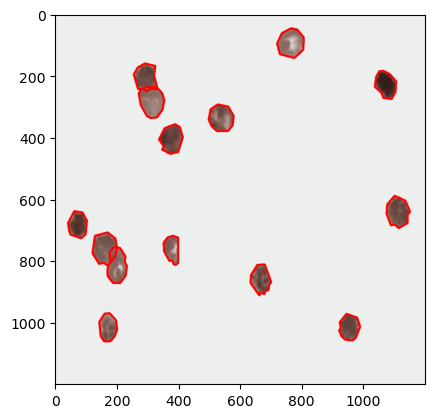

In [32]:
for polygon in bounding_polygons:
    pts = (polygon * np.array([sample[0].shape[1], sample[0].shape[0]])).reshape(-1, 1, 2).astype(np.int32)
    cv2.polylines(sample[0], [pts], True, (255, 0, 0), 5)
plt.imshow(sample[0].astype(np.uint8))
#plt.imshow(sample[0], vmin=0.0, vmax=1.0)

# Generate dataset

In [40]:
max_cells_count = 20
min_cells_count = 1
images_size = (640, 640)
train_images_count = 200
test_images_count = 50
yolo_dataset_path = "lab6/dataset_2"

In [41]:
os.makedirs(os.path.join(yolo_dataset_path, "train", "images"), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, "test", "images"), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, "train", "labels"), exist_ok=True)
os.makedirs(os.path.join(yolo_dataset_path, "test", "labels"), exist_ok=True)

In [42]:
with open(os.path.join(yolo_dataset_path, "dataset.yaml"), "w") as f:
    f.write(
f"""
train: train/images
val: test/images
names:
    0: cell
"""
    )

In [43]:
def figure_out_object_filename(dataset: BloodCellsDataset, i: int):
    dataset_len_str_len = len(str(len(dataset)))
    i_str_len = len(str(i))
    return f"{'0' * (dataset_len_str_len - i_str_len)}{i}"

In [44]:
train_dataset = BloodCellsDataset(device, images_size, train_images_count, dataset_prep, min_cells_count=min_cells_count, max_cells_count=max_cells_count, no_out_of_bounds=True)
test_dataset = BloodCellsDataset(device, images_size, test_images_count, dataset_prep, min_cells_count=min_cells_count, max_cells_count=max_cells_count, no_out_of_bounds=True)
for selected_dataset, selected_dataset_type in ((train_dataset, "train"), (test_dataset, "test")):
    temp_dataset_path = os.path.join(yolo_dataset_path, selected_dataset_type)
    for i in range(len(selected_dataset)):
        sample = selected_dataset[i]
        img = sample[0].cpu().numpy().astype(np.uint8)
        bounding_polygons = list(map(lambda x: x.cpu().numpy(), sample[5]))
        filename = figure_out_object_filename(selected_dataset, i)
        cv2.imwrite(os.path.join(temp_dataset_path, "images", filename + ".png"), img)
        with open(os.path.join(temp_dataset_path, "labels", filename + ".txt"), "w") as f:
            for j in range(len(bounding_polygons)):
                f.write(
                    f"0 {' '.join(map(str, bounding_polygons[j].flatten()))}\n"
                )

# Training

In [45]:
model = YOLO("yolov8n-seg.yaml")

model.train(data=os.path.join(yolo_dataset_path, "dataset.yaml"), epochs=100, save_dir="lab6/yolo_training")

New https://pypi.org/project/ultralytics/8.4.47 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.34 🚀 Python-3.14.3 torch-2.11.0 CPU (12th Gen Intel Core i7-12700K)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=lab6/dataset_2/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_tra

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fe9beb53540>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [46]:
model = YOLO("lab6/yolo_training/weights/best.pt")
model_results = model.val(save_dir="lab6/yolo_testing", save_txt=True, save_conf=True)
model_results.summary()

Ultralytics 8.4.34 🚀 Python-3.14.3 torch-2.11.0 CPU (12th Gen Intel Core i7-12700K)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4426.8±2785.6 MB/s, size: 88.6 KB)
val: Scanning lab6/dataset_2/test/labels.cache... 50 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 30.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2s/it 4.8s2.3ss
                   all         50        436      0.965      0.961      0.991      0.902      0.961      0.956      0.988      0.804
Speed: 0.7ms preprocess, 52.7ms inference, 0.0ms loss, 12.2ms postprocess per image
Results saved to lab6/yolo_testing


[{'Class': 'cell',
  'Images': np.int64(50),
  'Instances': np.int64(436),
  'Box-P': np.float64(0.96544),
  'Box-R': np.float64(0.96105),
  'Box-F1': np.float64(0.96324),
  'mAP50': np.float64(0.99076),
  'mAP50-95': np.float64(0.90211),
  'Mask-P': np.float64(0.96083),
  'Mask-R': np.float64(0.95646),
  'Mask-F1': np.float64(0.95864)}]

In [48]:
cell_min_conf = 0.8

In [49]:
def get_file_lines_count(path: str)->int:
    with open(path, "r") as f:
        res = 0
        for l in f:
            if len(l.strip()) != 0:
                res += 1
        return res

cells_count_results = []
for i in range(test_images_count):
    filename = figure_out_object_filename(test_dataset, i) + ".txt"
    test_cells_count = get_file_lines_count(os.path.join(yolo_dataset_path, "test", "labels", filename))
    got_cells_count = 0
    with open(os.path.join("lab6/yolo_testing/labels", filename), "r") as f:
        for l in f:
            if len(l.strip()) != "":
                conf = float(l.strip().split()[-1])
                if conf >= cell_min_conf:
                    got_cells_count += 1
    cells_count_results.append(1.0 - float(abs(test_cells_count - got_cells_count)) / float(max_cells_count - min_cells_count + 1))
    assert(0.0 <= cells_count_results[-1] <= 1.0)
np.mean(cells_count_results)

np.float64(0.9330000000000002)

In [99]:
def show_res_polygons(img: np.array, label_path: str, test_conf: bool):
    img = np.copy(img)
    sample_res = []
    sample_conf = []
    with open(label_path, "r") as f:
        for l in f:
            line = l.strip()
            if len(line) != 0:
                line = line.split()
                if not test_conf:
                    conf = 1.0
                    real_line_len = len(line)
                else:
                    conf = float(line[-1])
                    real_line_len = len(line) - 1
                if conf >= cell_min_conf:
                    sample_res.append([])
                    for i in range(1, real_line_len, 2):
                        sample_res[-1].append([float(line[i]), float(line[i+1])])
                    sample_conf.append(conf)
    for i in range(len(sample_res)):
        polygon = (np.array(sample_res[i]) * np.array([img.shape[1], img.shape[0]])).astype(np.int32).reshape(-1, 1, 2)
        if test_conf:
            print(polygon.shape, sample_conf[i])
        else:
            print(polygon.shape)
        cv2.polylines(img, [polygon], True, (255, 0, 0), 5)
    plt.imshow(img)

In [100]:
sample_filename = figure_out_object_filename(test_dataset, 0)
sample = cv2.imread(os.path.join(yolo_dataset_path, "test", "images", sample_filename + ".png"))

(132, 1, 2) 0.966341
(108, 1, 2) 0.962959
(76, 1, 2) 0.948782
(42, 1, 2) 0.924299
(64, 1, 2) 0.893085
(29, 1, 2) 0.892573
(18, 1, 2) 0.890139
(51, 1, 2) 0.860737


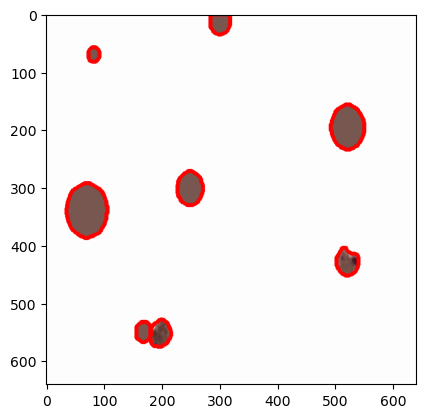

In [101]:
# yolo result
show_res_polygons(sample, os.path.join("lab6/yolo_testing/labels", sample_filename + ".txt"), True)

(7, 1, 2)
(10, 1, 2)
(9, 1, 2)
(8, 1, 2)
(12, 1, 2)
(12, 1, 2)
(8, 1, 2)
(12, 1, 2)


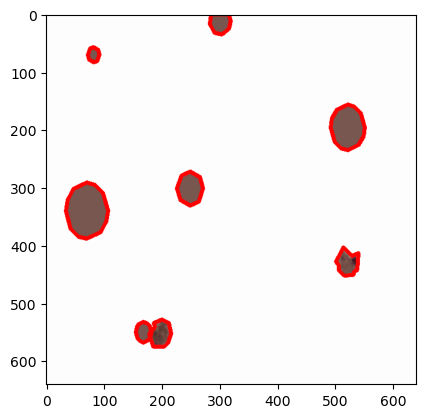

In [102]:
# Actual test
show_res_polygons(sample, os.path.join(yolo_dataset_path, "test", "labels", sample_filename + ".txt"), False)